# 04 — честный combined baseline (правильная pump-модель)

Исправляем расхождение из nb00–03: там pump был собран на машинерии dump'а (price-step + 20% стоп).
Здесь оба лега — из своих родных тредов:

- **PUMP** (`notebooks/pump/11` + `13/14`): SHORT по +5%/15m И vol>3×, **scale-in по времени** (транш на каждый ре-триггер, ramped), **3% стоп** на средний вход, 4ч выход, WF-классификатор (pred>0). Берём per-event net pnl из `pump_features_3y.npz`.
- **DUMP** (1:1 с боевым ботом): LONG по −7%/15m, **scale-in price-step** (−2% шаги), **20% катастрофный стоп**, 4ч, WF-классификатор на **тех же 12 фичах что считает бот** (med240), **БЕЗ KS** (бот его не реализует). Пересобран в `_out/dump_faithful.parquet`.

**Прогон:** $1000, один счёт, **2% эквити на позицию** (реинвест), набираем пока есть капитал (без резерва). Эквити — в линейных ценах, полный срез статистики.

In [1]:
import sys; sys.path.insert(0,'.')
from _lab import *
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PUMP leg: faithful scale-in + 3% stop (notebooks/pump) + walk-forward classifier ----
d=np.load('../pump/_out/pump_features_3y.npz',allow_pickle=True)
X,y,ts,off=d['X'],d['y'],d['ts'],d['off']
o=np.argsort(ts); X,y,ts,off=X[o],y[o],ts[o],off[o]; N=len(y)
bounds=[0.40,0.55,0.70,0.85,1.00]; pred=np.full(N,np.nan)
for a,b in zip(bounds[:-1],bounds[1:]):
    i0,i1=int(N*a),int(N*b)
    mdl=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
        l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(X[:i0],y[:i0])
    pred[i0:i1]=mdl.predict(X[i0:i1])
keepP=(pred>0)|np.isnan(pred)        # train region (no pred) unfiltered; OOS keep pred>0
entryP=pd.to_datetime(ts).tz_localize(None); exitP=entryP+pd.to_timedelta(off,'m')
pump=pd.DataFrame({'entry':entryP,'exit_ts':exitP,'pnl':y,'stream':'pump'})[keepP].reset_index(drop=True)

# ---- DUMP leg: 1:1 with the live bot (price-step + 20% stop + 12-feat med240 clf, NO KS) ----
dump=pd.read_parquet('_out/dump_faithful.parquet')
dump['entry']=pd.to_datetime(dump.entry).dt.tz_localize(None)
dump['exit_ts']=pd.to_datetime(dump.exit_ts).dt.tz_localize(None)

both=pd.concat([pump,dump]).sort_values('entry').reset_index(drop=True)
print(f'PUMP  kept {len(pump):5d}  per-trade net {pump.pnl.mean()*100:+.2f}%  win {(pump.pnl>0).mean()*100:.0f}%')
print(f'DUMP  kept {len(dump):5d}  per-trade net {dump.pnl.mean()*100:+.2f}%  win {(dump.pnl>0).mean()*100:.0f}%')
print(f'BOTH  {len(both)} signals   {both.entry.min().date()} .. {both.entry.max().date()}')

PUMP  kept  6256  per-trade net +0.98%  win 54%
DUMP  kept  3840  per-trade net +5.48%  win 74%
BOTH  10096 signals   2024-01-01 .. 2026-04-30


In [2]:
# ---- ONE account: $1000, 2% per position, reinvest, open while capital available ----
START=1000.; PCT=0.02
def run(df):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    pnl=df.pnl.values; stream=df.stream.values
    cash=START; dep=0.; openh=[]; eq_t=[];eq_v=[]; g_t=[];g_v=[]; nopen=[]
    taken=[]; skipped=0; maxc=0; maxg=0.
    def snap(t):
        eq=cash+dep; eq_t.append(pd.Timestamp(t)); eq_v.append(eq)
        g_t.append(pd.Timestamp(t)); g_v.append(dep/eq if eq>0 else 0.0); nopen.append(len(openh))
    for i in range(len(pnl)):
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(_)
        eq=cash+dep; no=PCT*eq
        if cash>=no and no>0:
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,pnl[i],stream[i]))
            taken.append((pnl[i],no,stream[i])); maxc=max(maxc,len(openh)); maxg=max(maxg,dep/(cash+dep)); snap(en[i])
        else:
            skipped+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn);dep-=no;snap(_)
    eq=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index(); eq=eq[~eq.index.duplicated(keep='last')].resample('1D').last().ffill()
    gr=pd.Series(g_v,index=pd.to_datetime(g_t)).sort_index()
    grmax=gr.resample('1D').max().ffill(); grmean=gr.resample('1D').mean().ffill()
    return eq,grmax,grmean,cash,pd.DataFrame(taken,columns=['pnl','notional','stream']),skipped,maxc,maxg,np.mean(nopen)

eq,grmax,grmean,fin,tk,skipped,maxc,maxg,avgc=run(both)
tk['pnl_usd']=tk.notional*tk.pnl
r=eq.pct_change().dropna(); span=(eq.index[-1]-eq.index[0]).days/365.25
sh=r.mean()/r.std()*np.sqrt(365); sortino=r.mean()/r[r<0].std()*np.sqrt(365)
dd=(eq.values/np.maximum.accumulate(eq.values)-1).min()
pos=tk.pnl_usd[tk.pnl_usd>0].sum(); neg=tk.pnl_usd[tk.pnl_usd<0].sum()
L=tk.pnl<=0
print('================  FAITHFUL COMBINED — $1000, 2%/pos, ONE account  ================')
print(f'span                       {span:.2f} y  ({eq.index.min().date()} .. {eq.index.max().date()})')
print(f'final equity               ${fin:,.0f}')
print(f'total return               {(fin/START-1)*100:+.0f}%')
print(f'CAGR                       {((fin/START)**(1/span)-1)*100:+.0f}%')
print(f'Sharpe / Sortino (daily)   {sh:.2f} / {sortino:.2f}')
print(f'maxDD                      {dd:.1%}')
print( '-'*70)
print(f'signals total              {len(both)}')
print(f'trades taken               {len(tk)}   (pump {len(tk[tk.stream=="pump"])}, dump {len(tk[tk.stream=="dump"])})')
print(f'skipped (no free capital)  {skipped}  ({skipped/len(both)*100:.0f}%)')
print( '-'*70)
print(f'avg trade                  {tk.pnl.mean()*100:+.2f}%   (median {tk.pnl.median()*100:+.2f}%)')
print(f'avg $ per trade            ${tk.pnl_usd.mean():+.2f}')
print(f'win rate                   {(tk.pnl>0).mean()*100:.1f}%')
print(f'losing trades              {L.sum()}  ({L.mean()*100:.0f}%)')
print(f'best / worst trade         {tk.pnl.max()*100:+.1f}% / {tk.pnl.min()*100:+.1f}%')
print(f'std / q10 per trade        {tk.pnl.std()*100:.2f}% / {np.quantile(tk.pnl,.1)*100:+.1f}%')
print(f'profit factor ($)          {pos/abs(neg):.2f}')
print(f'realized $ pnl total       ${tk.pnl_usd.sum():,.0f}')
print( '-'*70)
print(f'max concurrent positions   {maxc}')
print(f'max capital deployed/moment {maxg*100:.0f}% of equity')
print(f'avg capital deployed       {grmean.mean()*100:.0f}% of equity (time-weighted; \u2248 {grmean.mean()/PCT:.1f} \u043f\u043e\u0437\u0438\u0446\u0438\u0439 \u0432 \u0441\u0440\u0435\u0434\u043d\u0435\u043c)')
print('-'*70)
print('per-stream:')
for st in ['pump','dump']:
    g=tk[tk.stream==st]
    print(f'  {st:5} n={len(g):5d}  avg {g.pnl.mean()*100:+.2f}%  win {(g.pnl>0).mean()*100:.0f}%  $pnl ${g.pnl_usd.sum():,.0f}')

================  FAITHFUL COMBINED — $1000, 2%/pos, ONE account  ================
span                       2.33 y  (2024-01-01 .. 2026-04-30)
final equity               $13,353
total return               +1235%
CAGR                       +205%
Sharpe / Sortino (daily)   4.74 / 6.02
maxDD                      -13.2%
----------------------------------------------------------------------
signals total              10096
trades taken               7502   (pump 5365, dump 2137)
skipped (no free capital)  2594  (26%)
----------------------------------------------------------------------
avg trade                  +1.77%   (median +1.90%)
avg $ per trade            $+1.65
win rate                   61.5%
losing trades              2892  (39%)
best / worst trade         +89.9% / -23.9%
std / q10 per trade        6.93% / -4.2%
profit factor ($)          2.19
realized $ pnl total       $12,353
----------------------------------------------------------------------
max concurrent positions   50

[saved] notebooks\pump_dump_combined\_out\comb_04_equity.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_04_equity.png')

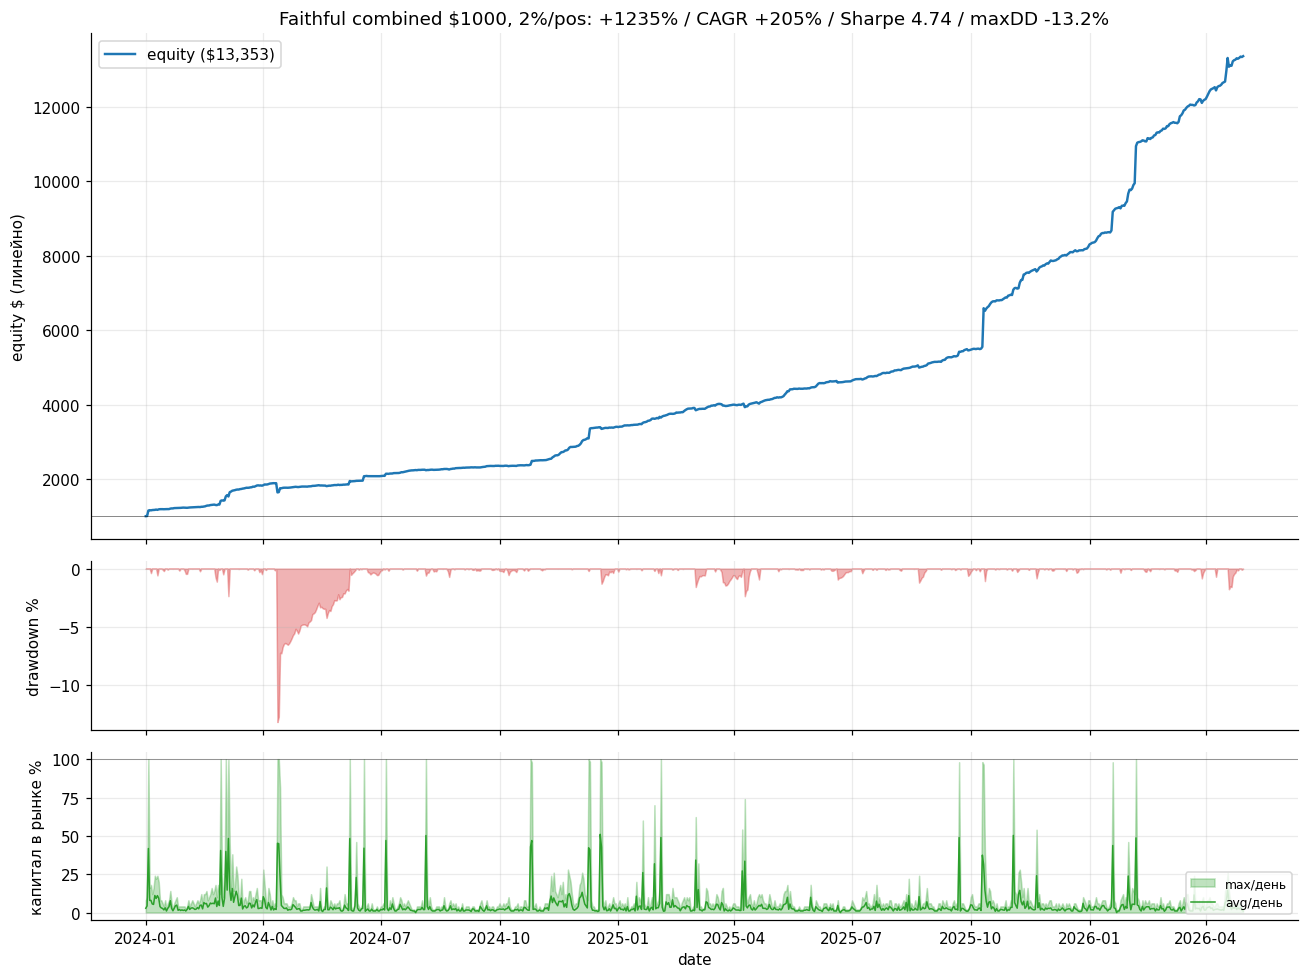

In [3]:
# ---- equity (LINEAR), drawdown, capital deployed ----
import matplotlib.pyplot as plt
fig,ax=plt.subplots(3,1,figsize=(12,9),sharex=True,gridspec_kw={'height_ratios':[3,1,1]})
ax[0].plot(eq.index,eq.values,color='#1f77b4',lw=1.6,label=f'equity (${fin:,.0f})')
ax[0].axhline(START,color='k',lw=.6,alpha=.5)
ax[0].set_ylabel('equity $ (\u043b\u0438\u043d\u0435\u0439\u043d\u043e)'); ax[0].legend(loc='upper left')
ax[0].set_title(f'Faithful combined $1000, 2%/pos: {(fin/START-1)*100:+.0f}% / CAGR {((fin/START)**(1/span)-1)*100:+.0f}% / Sharpe {sh:.2f} / maxDD {dd:.1%}')
ddc=(eq/eq.cummax()-1)*100
ax[1].fill_between(ddc.index,ddc.values,0,color='#d62728',alpha=.35); ax[1].set_ylabel('drawdown %')
ax[2].fill_between(grmax.index,grmax.values*100,0,color='#2ca02c',alpha=.30,label='max/\u0434\u0435\u043d\u044c')
ax[2].plot(grmean.index,grmean.values*100,color='#2ca02c',lw=1.0,label='avg/\u0434\u0435\u043d\u044c')
ax[2].axhline(100,color='k',lw=.6,alpha=.4); ax[2].set_ylabel('\u043a\u0430\u043f\u0438\u0442\u0430\u043b \u0432 \u0440\u044b\u043d\u043a\u0435 %'); ax[2].set_xlabel('date'); ax[2].legend(fontsize=8,loc='lower right')
show('comb_04_equity')

## Итог

Combined **1:1 с боевым ботом** (pump: 3% стоп + time-scale-in; dump: price-step + 20% стоп + 12-фич med240, БЕЗ KS)
на $1000, 2%/позицию: **≈$13.4k (+1235%), Sharpe 4.74, maxDD −13.2%.**

**Что изменилось от убирания KS (бот его не имеет):** dump-сигналов стало больше (10096 vs 8389),
per-trade kept dump подскочил до +5.48% (KS раньше выкидывал самые прибыльные кластерные дни — dump nb09:
97% прибыли в топ-20 днях). Но за это: **просадка глубже (−13.2% vs −11.9%)** и **пропусков по капиталу 26% vs 11%**
(без KS в коррелированные кластера набивается больше сигналов → чаще упираемся в капитал). Это ровно тот
trade-off, про который предупреждал dump nb09: KS = страховка, стоит доходности in-sample, платит в каскаде.

**Структура риска:** при 2%/поз без резерва капитал доходит до 100% в рынке (max 50 одновременных),
в среднем по времени ~4% (≈2 позиции); полная загрузка — короткими всплесками в кластерах.

**Оговорки:** in-sample 2024–04.2026; без модели ёмкости/слиппеджа (идеальное исполнение — реальный абсолют ниже, см. nb02); pnl net комиссий (0.15% round-trip), без рыночного импакта; классификаторы тонкие, train-регион без фильтра. Новый baseline, теперь точно соответствует боту.